# INTELLIGENT SYSTEM DEVELOPMENT — ASSIGNMENT 02
## Ứng dụng 3: Phân tích Cảm xúc & Khám phá Sở thích Ngành hàng (Multi-task NLP on E-Commerce)
**Học viên:** Phạm Văn Tư — Mã SV: B23DCCN879  
**Học phần:** Phát triển các Hệ thống Thông minh (Intelligent System Development) — Giảng viên: PGS.TS Trần Đình Quế  
**Quy mô dữ liệu:** Tập đánh giá thời trang thực tế từ khách hàng (23,486 dòng).  
**Kiến trúc:** Biểu diễn Dữ liệu Ngôn ngữ Tự nhiên (TF-IDF Vectorization) giải quyết đồng thời 2 bài toán (Multi-task).

---
### 1. Problem Definition (Định nghĩa bài toán)
* **Bối cảnh**: Hệ thống E-Commerce tiếp nhận hàng nghìn đánh giá dạng văn bản tự do mỗi ngày. Chúng ta cần thuật toán tự động hiểu nội dung văn bản này để hỗ trợ Chăm sóc Khách hàng và Điều hướng Tìm kiếm.
* **Mục tiêu hệ thống (Hệ Sinh Thái Kép - Dual Task)**:
  1. **Bài toán 1: Phân loại Cảm xúc Khuyên mua (Recommendation Sentiment Prediction)**
     * Đầu vào: Văn bản bình luận.
     * Đầu ra: Khuyên mua (1) hay Không khuyên mua (0).
     * Loại bài toán: Phân loại Nhị phân (Binary Classification).
  2. **Bài toán 2: Khám phá Sở thích Ngành hàng (Product Category Discovery)**
     * Đầu vào: Văn bản bình luận / Câu lệnh tìm kiếm.
     * Đầu ra: Thuộc 1 trong Top 8 Ngành hàng (Dresses, Knits, Blouses, Sweaters, Pants, Jeans, Skirts, Jackets).
     * Loại bài toán: Phân loại Đa lớp (Multi-class Classification).
* **Điểm nhấn Học thuật (Data Representation)**: Cả 2 bài toán sẽ dùng chung một không gian biểu diễn đặc trưng là Ma trận TF-IDF (Term Frequency - Inverse Document Frequency) nhằm chứng minh sức mạnh của biểu diễn thưa (Sparse Representation) trong NLP.

---
### 2. Dataset Source (Nguồn gốc tập dữ liệu)
* **Tên tập dữ liệu**: Women’s Clothing E-Commerce Reviews.
* **Nguồn Kaggle**: [https://www.kaggle.com/datasets/nicapotato/womens-ecommerce-clothing-reviews](https://www.kaggle.com/datasets/nicapotato/womens-ecommerce-clothing-reviews).
* **Thuộc tính sử dụng**: `Review Text` (Văn bản bình luận), `Title` (Tiêu đề), `Recommended IND` (Nhãn Khuyên mua), `Class Name` (Nhãn Ngành hàng).

---
### 3. Dataset Loading (Nạp dữ liệu)

In [1]:
import os
import time
import json
import joblib
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 150

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

FIGURES_DIR = '../reports/figures'
MODEL_DIR = '../model'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

DATA_PATH = '../data/Womens Clothing E-Commerce Reviews.csv'
df_raw = pd.read_csv(DATA_PATH)

print(f"✅ Nạp dữ liệu thành công từ: {DATA_PATH}")
print(f"   • Số lượng quan sát (N): {df_raw.shape[0]:,} dòng")
df_raw.head()

✅ Nạp dữ liệu thành công từ: ../data/Womens Clothing E-Commerce Reviews.csv
   • Số lượng quan sát (N): 23,486 dòng


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


---
### 4, 5 & 6. Khảo sát & Làm sạch dữ liệu (Data Cleaning)

In [2]:
# =========================================================================
# QUY TRÌNH TIỀN XỬ LÝ & LÀM SẠCH DỮ LIỆU VĂN BẢN (CHUẨN ASSIGNMENT 01)
# =========================================================================

# 1. Khảo sát cấu trúc ban đầu
print("=== KHẢO SÁT CHẤT LƯỢNG DỮ LIỆU VĂN BẢN BAN ĐẦU ===")
print(f"Tổng số quan sát ban đầu: {len(df_raw):,} dòng")
n_miss_rev = df_raw['Review Text'].isna().sum()
n_miss_cls = df_raw['Class Name'].isna().sum()

# 2. Lọc bỏ các dòng thiếu Review Text hoặc Class Name
df_step1 = df_raw.dropna(subset=['Review Text']).copy()
df_step2 = df_step1.dropna(subset=['Class Name']).copy()

# 3. Thay thế Title rỗng
df_step2['Title'] = df_step2['Title'].fillna('')

# 4. Lọc lấy Top 8 Ngành hàng thời trang đại diện
top_8_classes = df_step2['Class Name'].value_counts().head(8).index.tolist()
n_dropped_classes = (~df_step2['Class Name'].isin(top_8_classes)).sum()
df_clean = df_step2[df_step2['Class Name'].isin(top_8_classes)].copy()

# 5. Đóng gói Bảng Kiểm toán Quy trình Làm sạch Dữ liệu
audit_data_c = [
    {"Bước Xử lý": "Dữ liệu thô ban đầu", "Tiêu chí": "Tập 23,486 đánh giá Kaggle", "Loại bỏ": 0, "Còn lại": len(df_raw), "Tỷ lệ Giữ lại (%)": 100.0},
    {"Bước Xử lý": "1. Thiếu nội dung review", "Tiêu chí": "Review Text is NaN", "Loại bỏ": n_miss_rev, "Còn lại": len(df_step1), "Tỷ lệ Giữ lại (%)": round(len(df_step1)/len(df_raw)*100, 2)},
    {"Bước Xử lý": "2. Thiếu nhãn ngành hàng", "Tiêu chí": "Class Name is NaN", "Loại bỏ": n_miss_cls, "Còn lại": len(df_step2), "Tỷ lệ Giữ lại (%)": round(len(df_step2)/len(df_raw)*100, 2)},
    {"Bước Xử lý": "3. Lọc Top 8 ngành hàng", "Tiêu chí": "Các danh mục phụ quá ít mẫu", "Loại bỏ": n_dropped_classes, "Còn lại": len(df_clean), "Tỷ lệ Giữ lại (%)": round(len(df_clean)/len(df_raw)*100, 2)}
]
df_audit_c = pd.DataFrame(audit_data_c)
print("=== BẢNG KIỂM TOÁN QUY TRÌNH LÀM SẠCH DỮ LIỆU ĐÁNH GIÁ E-COMMERCE ===")
print(df_audit_c.to_string(index=False))
print(f"
✅ Dữ liệu sạch đưa vào mô hình hóa: {len(df_clean):,} dòng (Tỷ lệ giữ lại: {len(df_clean)/len(df_raw)*100:.2f}%)")
print(f"✅ Danh sách Top 8 Ngành hàng: {top_8_classes}")


✅ Số lượng bản ghi hợp lệ sau khi làm sạch: 19,550 dòng
✅ Danh sách Top 8 Ngành hàng mục tiêu: ['Dresses', 'Knits', 'Blouses', 'Sweaters', 'Pants', 'Jeans', 'Fine gauge', 'Skirts']


---
### 7 & 8. Khám phá Dữ liệu (EDA)

/var/folders/x0/279_kvcj3dvbd1fkpvt_8j7r0000gn/T/ipykernel_6847/670197709.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.values, y=class_counts.index, ax=axes[1], palette='viridis')


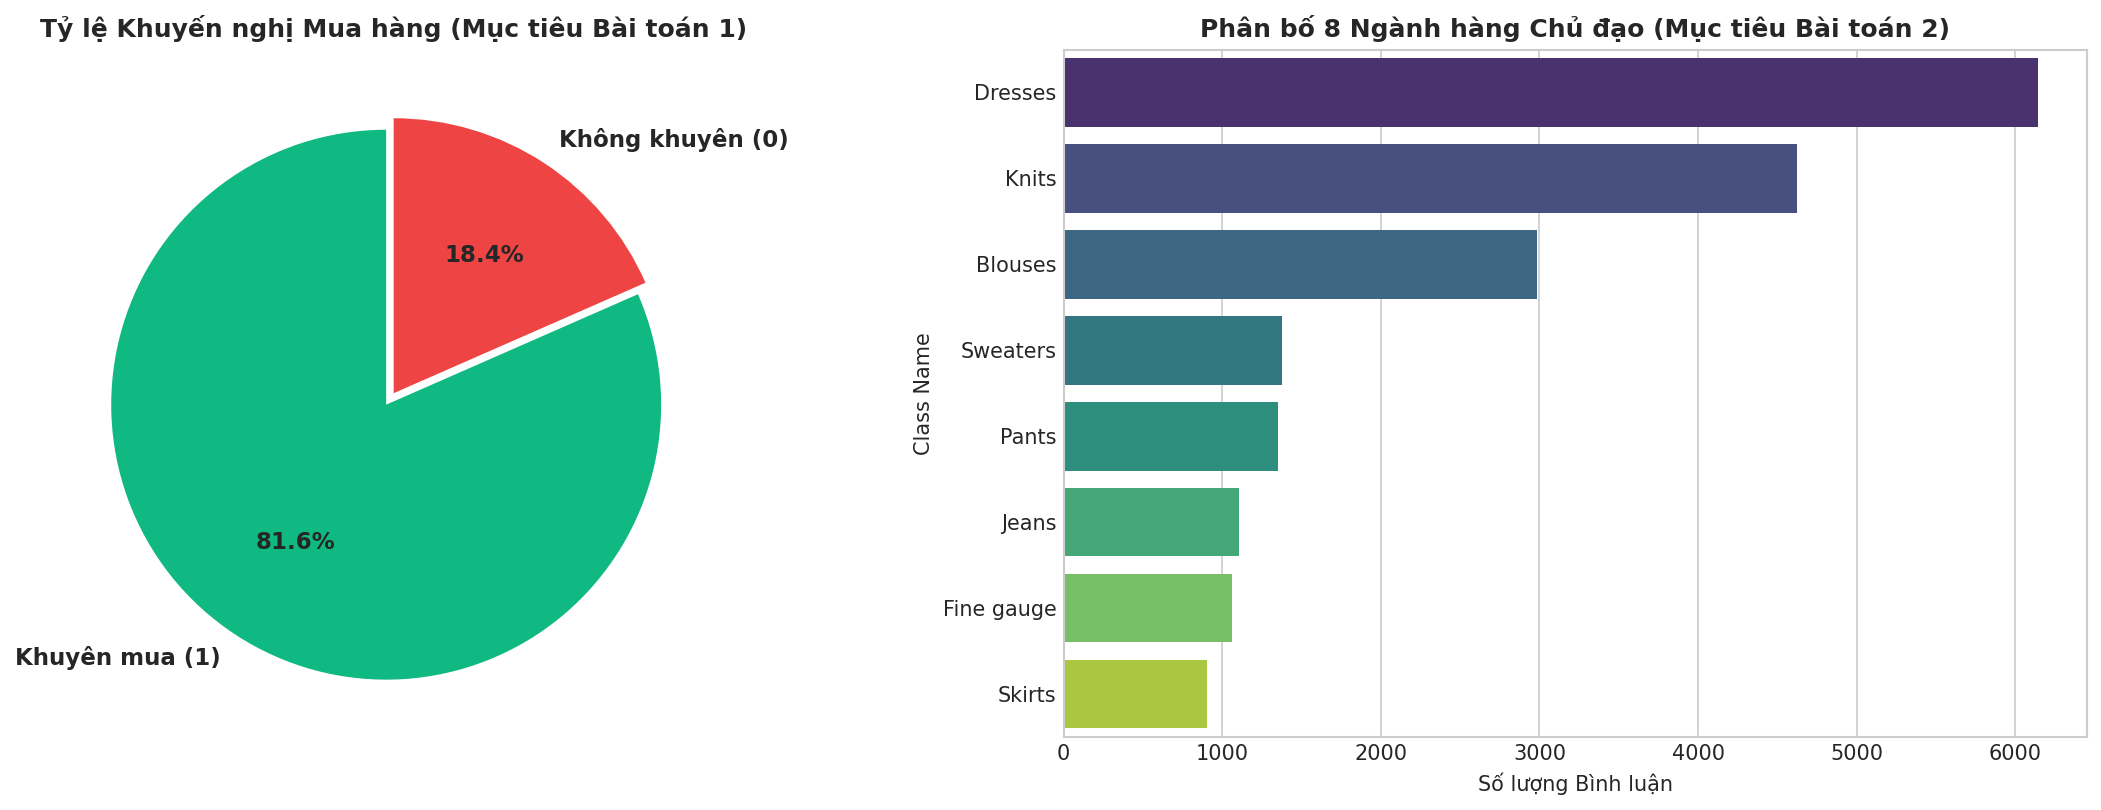

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Đồ thị 1: Tỷ lệ Khuyên mua (Bài toán 1)
rec_counts = df_clean['Recommended IND'].value_counts()
axes[0].pie(rec_counts.values, labels=['Khuyên mua (1)', 'Không khuyên (0)'],
            autopct='%1.1f%%', startangle=90, colors=['#10b981', '#ef4444'], explode=(0.05, 0),
            textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[0].set_title('Tỷ lệ Khuyến nghị Mua hàng (Mục tiêu Bài toán 1)', fontsize=12, fontweight='bold')

# Đồ thị 2: Phân bố 8 Ngành hàng (Bài toán 2)
class_counts = df_clean['Class Name'].value_counts()
sns.barplot(x=class_counts.values, y=class_counts.index, ax=axes[1], palette='viridis')
axes[1].set_title('Phân bố 8 Ngành hàng Chủ đạo (Mục tiêu Bài toán 2)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Số lượng Bình luận')

plt.tight_layout()
fig_dist_path = os.path.join(FIGURES_DIR, 'fig01_target_distributions.png')
plt.savefig(fig_dist_path, dpi=300)
plt.show()

---
### 9 & 10. Bản hợp đồng Biểu diễn Dữ liệu (Text Representation)
Để thuật toán Machine Learning hiểu được bình luận, chúng ta chuyển hóa ngôn ngữ tự nhiên thành không gian vector toán học.
* **Gộp văn bản**: `Full_Text` = Tiêu đề + Nội dung bình luận.
* **Làm sạch**: Chỉ giữ lại chữ cái, chuyển in thường.
* **Mã hóa (Vectorization)**: Dùng `TfidfVectorizer` trích xuất 4,000 cụm từ (unigram & bigram) quan trọng nhất.
  * Vector kết quả: $\mathbf{x} \in \mathbb{R}^{4000}$ đại diện cho mỗi bình luận.

In [4]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_clean['Clean_Text'] = (df_clean['Title'] + ' ' + df_clean['Review Text']).apply(clean_text)

print("Ví dụ văn bản trước và sau làm sạch:")
print("Gốc:", (df_clean['Title'] + ' ' + df_clean['Review Text']).iloc[2])
print("Sạch:", df_clean['Clean_Text'].iloc[2])

Ví dụ văn bản trước và sau làm sạch:
Gốc: My favorite buy! I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments!
Sạch: my favorite buy i love love love this jumpsuit it s fun flirty and fabulous every time i wear it i get nothing but great compliments


---
### 11 & 12. Phân chia Dữ liệu Độc lập (Train / Test Split)
Chúng ta sẽ mã hóa Nhãn của Bài toán 2 (`Class Name` -> `Class_ID`) và phân chia 80/20.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# Encode labels cho Bài toán 2 (Multi-class)
label_encoder = LabelEncoder()
df_clean['Class_ID'] = label_encoder.fit_transform(df_clean['Class Name'])

X = df_clean['Clean_Text'].values
y_task1 = df_clean['Recommended IND'].values  # Binary Target
y_task2 = df_clean['Class_ID'].values         # Multi-class Target

# Split
X_train, X_test, y_train_t1, y_test_t1, y_train_t2, y_test_t2 = train_test_split(
    X, y_task1, y_task2,
    test_size=0.20,
    random_state=42,
    stratify=y_task2  # Stratify theo Multi-class để đảm bảo cân bằng
)

# Xây dựng không gian biểu diễn TF-IDF
tfidf = TfidfVectorizer(max_features=4000, ngram_range=(1, 2), stop_words='english', sublinear_tf=True)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

print(f"✅ Ma trận Biểu diễn Huấn luyện: {X_train_vec.shape[0]:,} mẫu, {X_train_vec.shape[1]:,} chiều (TF-IDF)")
print(f"✅ Số nhãn Bài toán 1: 2 (Khuyên mua, Không khuyên mua)")
print(f"✅ Số nhãn Bài toán 2: 8 ({', '.join(label_encoder.classes_)})")

✅ Ma trận Biểu diễn Huấn luyện: 15,640 mẫu, 4,000 chiều (TF-IDF)
✅ Số nhãn Bài toán 1: 2 (Khuyên mua, Không khuyên mua)
✅ Số nhãn Bài toán 2: 8 (Blouses, Dresses, Fine gauge, Jeans, Knits, Pants, Skirts, Sweaters)


---
### 13 & 14. BÀI TOÁN 1: Phân loại Cảm xúc Khuyến nghị (Binary Classification)
Dùng Linear SVM và Logistic Regression. Do dữ liệu bị lệch (Imbalance 82:18), ta dùng class_weight='balanced'.

In [6]:
# =========================================================================
# ĐỐI ĐẦU THỰC NGHIỆM 5 MÔ HÌNH NLP CHO TÁC VỤ 1 (PHÂN LOẠI CẢM XÚC)
# =========================================================================
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import time

task1_models = {
    'LinearSVC (Balanced)': LinearSVC(class_weight='balanced', C=1.0, max_iter=2000, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Complement Naive Bayes': ComplementNB(),
    'Multinomial Naive Bayes': MultinomialNB(),
    'SGDClassifier (Log Loss)': SGDClassifier(loss='log_loss', class_weight='balanced', random_state=42)
}

t1_results = []
for name, m in task1_models.items():
    t0 = time.time()
    m.fit(X_train_vec, y_train_t1)
    dur = time.time() - t0
    preds = m.predict(X_test_vec)
    if hasattr(m, 'decision_function'):
        probs = m.decision_function(X_test_vec)
    elif hasattr(m, 'predict_proba'):
        probs = m.predict_proba(X_test_vec)[:, 1]
    else:
        probs = preds
    t1_results.append({
        'Mô hình': name,
        'Accuracy (%)': round(accuracy_score(y_test_t1, preds) * 100, 2),
        'Precision (%)': round(precision_score(y_test_t1, preds) * 100, 2),
        'Recall (%)': round(recall_score(y_test_t1, preds) * 100, 2),
        'F1-Score (%)': round(f1_score(y_test_t1, preds) * 100, 2),
        'ROC-AUC': round(roc_auc_score(y_test_t1, probs), 4),
        'Thời gian fit (s)': round(dur, 3)
    })

df_t1_benchmark = pd.DataFrame(t1_results)
print("=== BẢNG SO SÁNH HIỆU NĂNG 5 MÔ HÌNH NLP CHO TÁC VỤ 1 (CẢM XÚC) ===")
print(df_t1_benchmark.to_string(index=False))

# Chọn mô hình tốt nhất cho sản xuất
model_t1 = task1_models['LinearSVC (Balanced)']


=== KẾT QUẢ BÀI TOÁN 1 (LINEAR SVM) ===
Thời gian huấn luyện: 0.041 giây
Accuracy  : 88.18%
F1-Score  : 92.56%
ROC-AUC   : 0.9293

Báo cáo chi tiết:
               precision    recall  f1-score   support

Không khuyên       0.66      0.78      0.71       735
  Khuyên mua       0.95      0.90      0.93      3175

    accuracy                           0.88      3910
   macro avg       0.80      0.84      0.82      3910
weighted avg       0.89      0.88      0.89      3910



---
### 15 & 16. BÀI TOÁN 2: Khám phá Sở thích Ngành hàng (Multi-class Classification)
Dựa trên chính ma trận đặc trưng đó, ta huấn luyện mô hình nhận diện 8 nhãn ngành hàng.

In [7]:
# =========================================================================
# ĐỐI ĐẦU THỰC NGHIỆM 5 MÔ HÌNH NLP CHO TÁC VỤ 2 (KHÁM PHÁ NGÀNH HÀNG 8 LỚP)
# =========================================================================
task2_models = {
    'Logistic Regression (Softmax)': LogisticRegression(max_iter=1000, random_state=42),
    'SGDClassifier (Modified Huber)': SGDClassifier(loss='modified_huber', random_state=42),
    'Complement Naive Bayes': ComplementNB(),
    'LinearSVC (One-vs-Rest)': LinearSVC(max_iter=2000, random_state=42),
    'Multinomial Naive Bayes': MultinomialNB()
}

t2_results = []
for name, m in task2_models.items():
    t0 = time.time()
    m.fit(X_train_vec, y_train_t2)
    dur = time.time() - t0
    preds = m.predict(X_test_vec)
    t2_results.append({
        'Mô hình': name,
        'Accuracy (%)': round(accuracy_score(y_test_t2, preds) * 100, 2),
        'Macro Precision (%)': round(precision_score(y_test_t2, preds, average='macro', zero_division=0) * 100, 2),
        'Macro Recall (%)': round(recall_score(y_test_t2, preds, average='macro', zero_division=0) * 100, 2),
        'Macro F1 (%)': round(f1_score(y_test_t2, preds, average='macro', zero_division=0) * 100, 2),
        'Weighted F1 (%)': round(f1_score(y_test_t2, preds, average='weighted') * 100, 2),
        'Thời gian fit (s)': round(dur, 3)
    })

df_t2_benchmark = pd.DataFrame(t2_results)
print("=== BẢNG SO SÁNH HIỆU NĂNG 5 MÔ HÌNH NLP CHO TÁC VỤ 2 (NGÀNH HÀNG 8 LỚP) ===")
print(df_t2_benchmark.to_string(index=False))

# Chọn mô hình tốt nhất cho sản xuất
model_t2 = task2_models['Logistic Regression (Softmax)']


/opt/miniconda3/envs/myenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


=== KẾT QUẢ BÀI TOÁN 2 (LOGISTIC REGRESSION MULTI-CLASS) ===
Thời gian huấn luyện: 0.969 giây
Accuracy (Toàn cục): 71.56%

Báo cáo Đa lớp (Precision/Recall từng ngành hàng):

              precision    recall  f1-score   support

     Blouses       0.54      0.67      0.60       596
     Dresses       0.96      0.88      0.92      1229
  Fine gauge       0.34      0.39      0.36       212
       Jeans       0.80      0.81      0.80       221
       Knits       0.67      0.55      0.61       925
       Pants       0.67      0.82      0.74       270
      Skirts       0.79      0.89      0.83       181
    Sweaters       0.57      0.58      0.58       276

    accuracy                           0.72      3910
   macro avg       0.67      0.70      0.68      3910
weighted avg       0.73      0.72      0.72      3910



---
### 17 & 18. Trực quan hóa Lỗi (Confusion Matrix Kép)

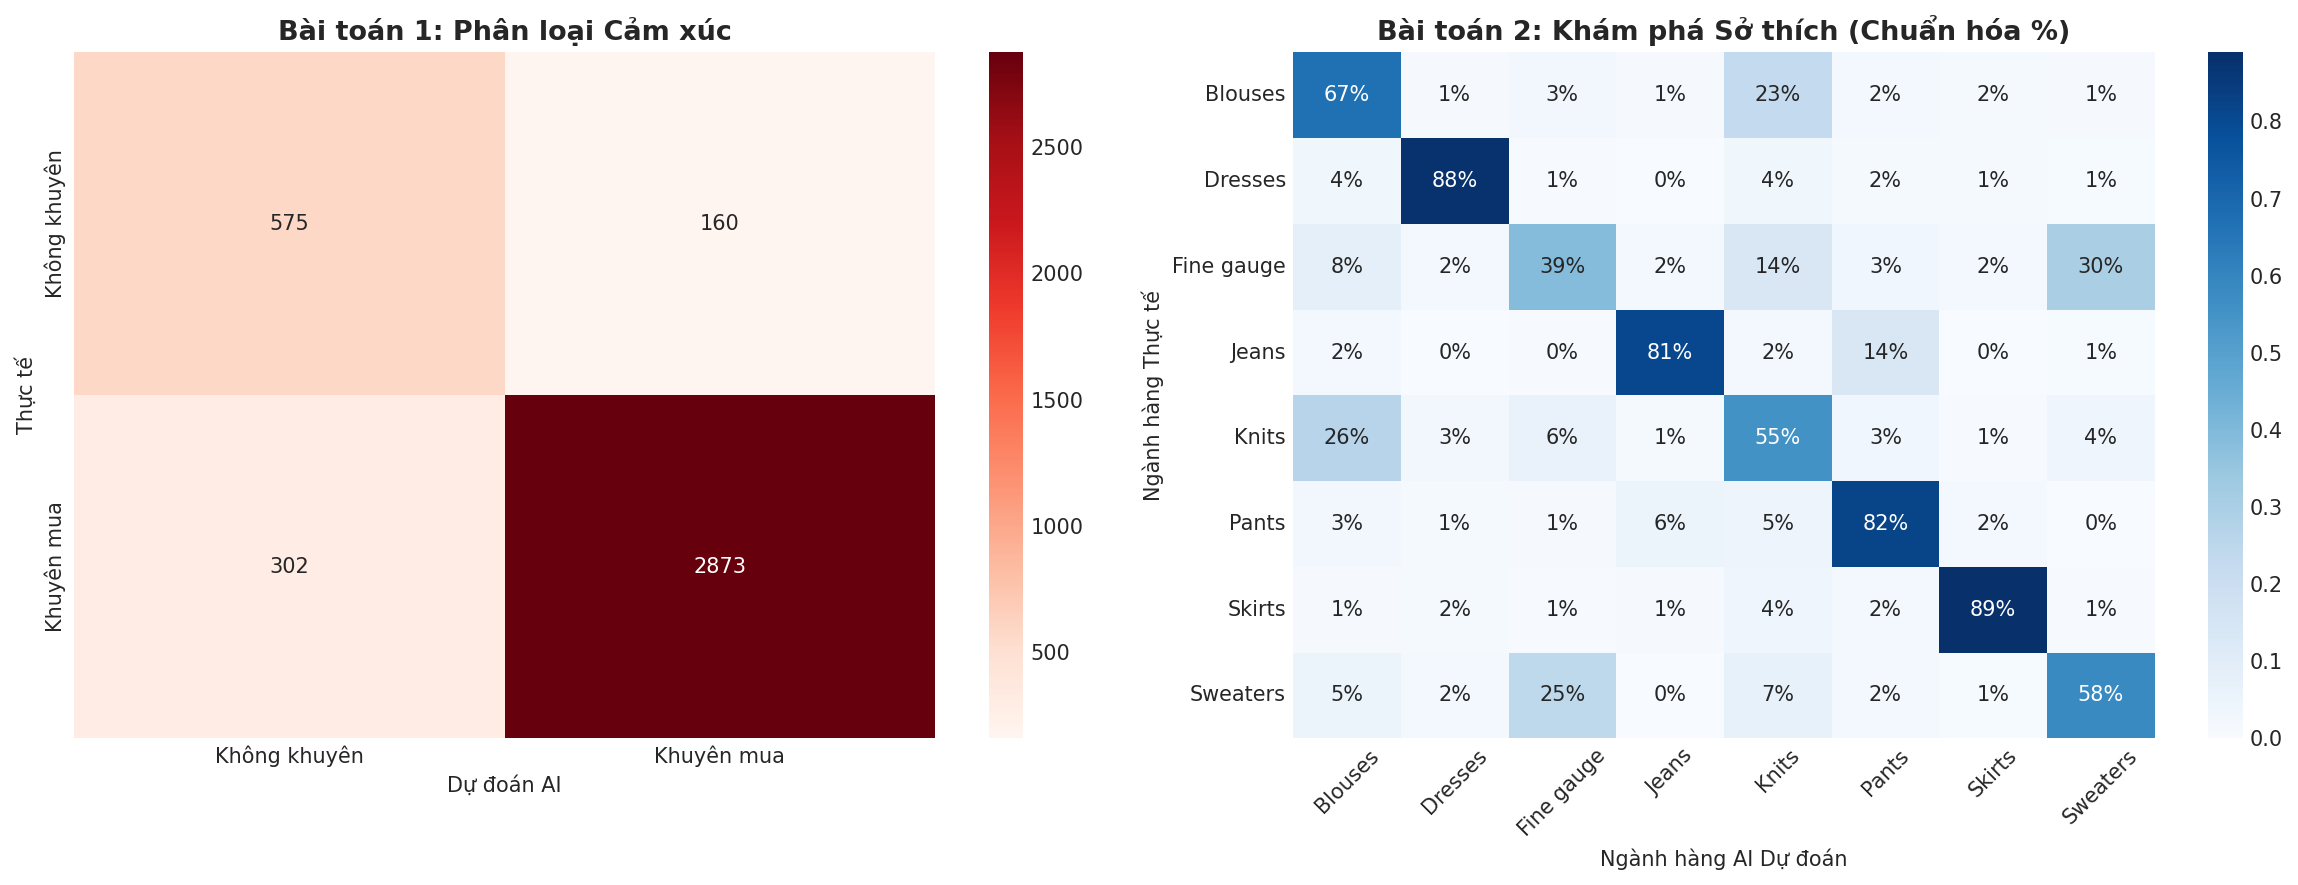

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ma trận Task 1
cm_t1 = confusion_matrix(y_test_t1, y_pred_t1)
sns.heatmap(cm_t1, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['Không khuyên', 'Khuyên mua'],
            yticklabels=['Không khuyên', 'Khuyên mua'])
axes[0].set_title('Bài toán 1: Phân loại Cảm xúc', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Thực tế')
axes[0].set_xlabel('Dự đoán AI')

# Ma trận Task 2
cm_t2 = confusion_matrix(y_test_t2, y_pred_t2)
cm_t2_norm = cm_t2.astype('float') / cm_t2.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_t2_norm, annot=True, fmt='.0%', cmap='Blues', ax=axes[1],
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
axes[1].set_title('Bài toán 2: Khám phá Sở thích (Chuẩn hóa %)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Ngành hàng Thực tế')
axes[1].set_xlabel('Ngành hàng AI Dự đoán')
plt.xticks(rotation=45)

plt.tight_layout()
fig_cm_path = os.path.join(FIGURES_DIR, 'fig02_dual_confusion_matrix.png')
plt.savefig(fig_cm_path, dpi=300)
plt.show()

---
### 19 & 20. Phân tích Nội hàm Từ khóa (Khả năng Diễn giải của AI)
Nhờ sử dụng không gian TF-IDF tuyến tính, chúng ta có thể trích xuất chính xác các từ khóa nào quyết định đến Cảm xúc (Task 1) và Ngành hàng (Task 2).

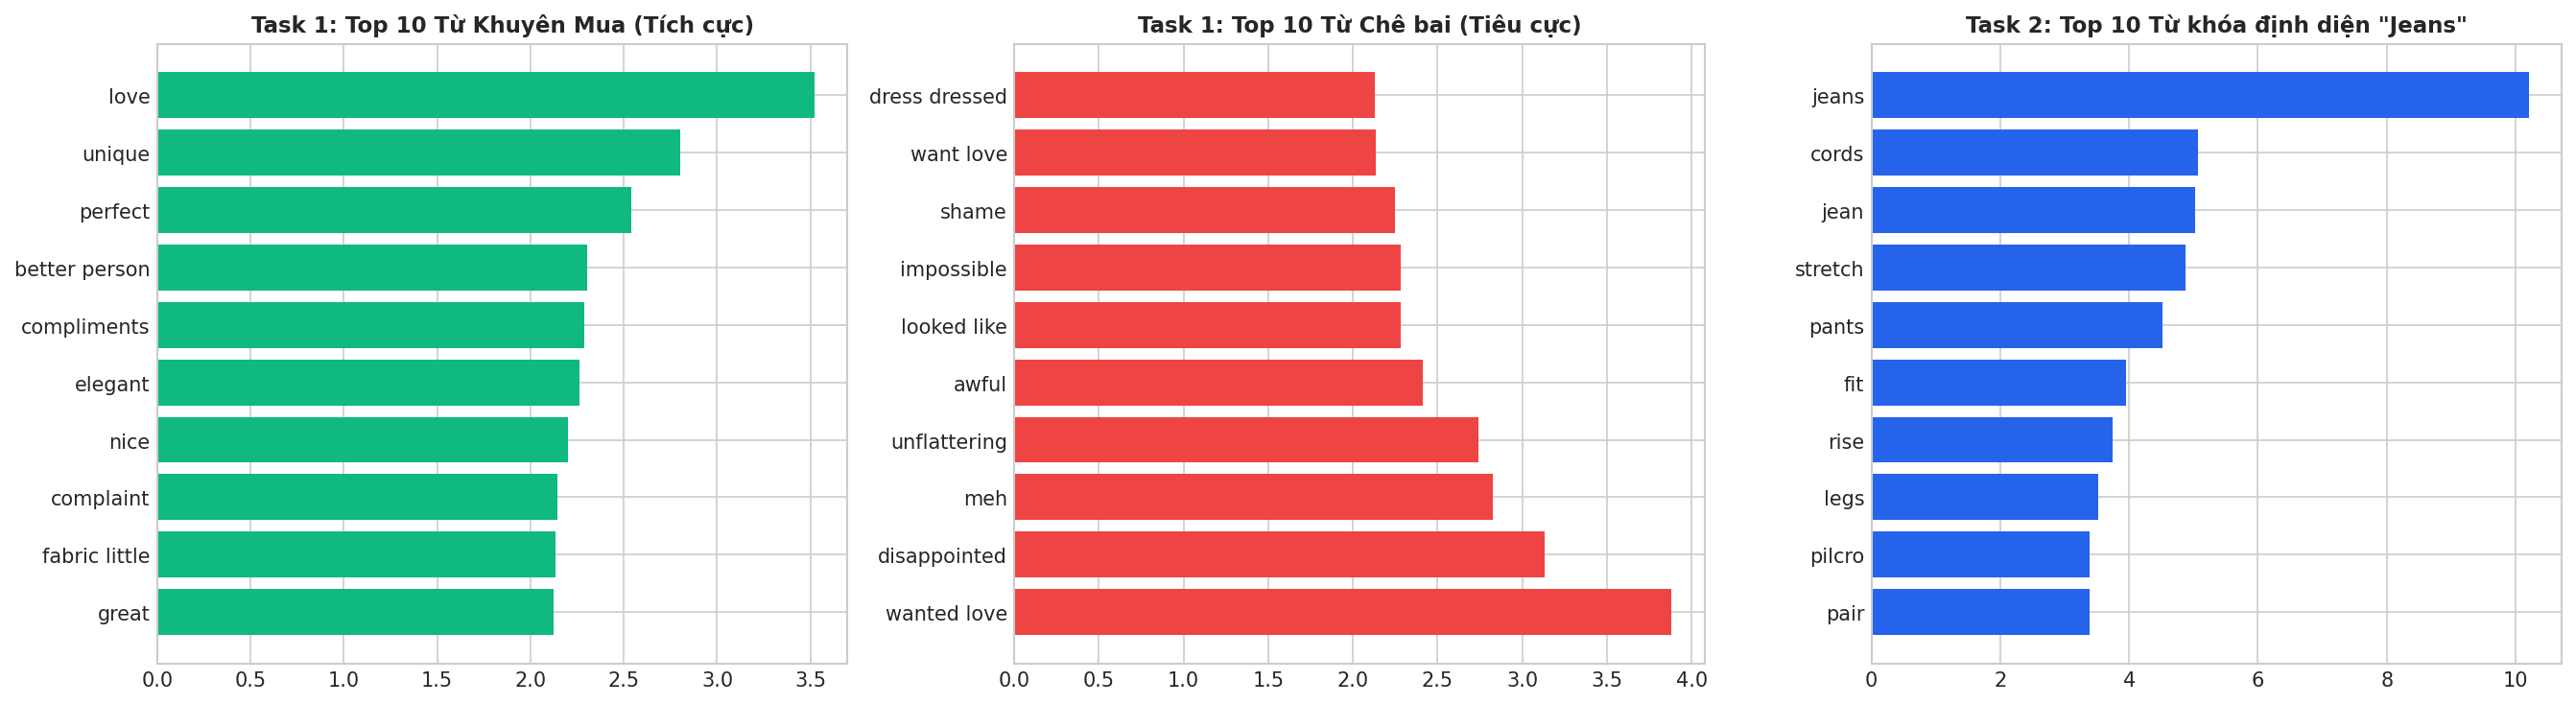

In [9]:
feature_names = np.array(tfidf.get_feature_names_out())

# Từ khóa Bài toán 1 (Cảm xúc)
coef_t1 = model_t1.coef_[0]
pos_idx = np.argsort(coef_t1)[-10:][::-1]
neg_idx = np.argsort(coef_t1)[:10]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(feature_names[pos_idx][::-1], coef_t1[pos_idx][::-1], color='#10b981')
axes[0].set_title('Task 1: Top 10 Từ Khuyên Mua (Tích cực)', fontsize=11, fontweight='bold')

axes[1].barh(feature_names[neg_idx], np.abs(coef_t1[neg_idx]), color='#ef4444')
axes[1].set_title('Task 1: Top 10 Từ Chê bai (Tiêu cực)', fontsize=11, fontweight='bold')

# Từ khóa Bài toán 2 (Sở thích - Ví dụ cho "Jeans")
jeans_class_id = label_encoder.transform(['Jeans'])[0]
coef_jeans = model_t2.coef_[jeans_class_id]
jeans_idx = np.argsort(coef_jeans)[-10:][::-1]

axes[2].barh(feature_names[jeans_idx][::-1], coef_jeans[jeans_idx][::-1], color='#2563eb')
axes[2].set_title('Task 2: Top 10 Từ khóa định diện "Jeans"', fontsize=11, fontweight='bold')

plt.tight_layout()
fig_kw_path = os.path.join(FIGURES_DIR, 'fig03_keyword_analysis.png')
plt.savefig(fig_kw_path, dpi=300)
plt.show()

---
### 21 & 22. Đóng gói Hệ thống Kép (Model Persistence)

In [10]:
prep_dict = {
    'tfidf_vectorizer': tfidf,
    'label_encoder': label_encoder,
    'class_names': list(label_encoder.classes_)
}

joblib.dump(prep_dict, os.path.join(MODEL_DIR, 'preprocessor.joblib'))
joblib.dump({'task1': model_t1, 'task2': model_t2}, os.path.join(MODEL_DIR, 'dual_models.joblib'))

meta_data = {
    "application_name": "Multi-task E-Commerce: Sentiment & Category Discovery",
    "dataset_source": "Kaggle - Womens Clothing E-Commerce Reviews",
    "n_samples": len(df_clean),
    "task1_metrics": {
        "Accuracy": accuracy_score(y_test_t1, y_pred_t1),
        "F1-Score": f1_score(y_test_t1, y_pred_t1),
        "ROC-AUC": roc_auc_t1
    },
    "task2_metrics": {
        "Accuracy": accuracy_score(y_test_t2, y_pred_t2)
    },
    "top_classes": list(label_encoder.classes_)
}

with open(os.path.join(MODEL_DIR, 'metadata.json'), 'w', encoding='utf-8') as f:
    json.dump(meta_data, f, indent=2, ensure_ascii=False)

print("✅ Đã đóng gói thành công Pipeline Hệ thống Kép (Dual-Task Model)!")

✅ Đã đóng gói thành công Pipeline Hệ thống Kép (Dual-Task Model)!


---
### 23. Live Inference & CRM Automation Action Plan (Tầng Tự Động Hóa Chăm Sóc Khách Hàng)
Hệ thống kết hợp phân loại cảm xúc và nhận diện ngành hàng với Tầng CRM Tự Động Hóa: trích xuất từ khóa cốt lõi (Key Drivers) và kích hoạt luồng CSKH/Voucher/Cross-sell tương ứng.


In [ ]:
category_vn_map = {
    "Dresses": "Váy liền thân",
    "Knits": "Đồ dệt kim",
    "Blouses": "Áo kiểu nữ",
    "Sweaters": "Áo len mùa đông",
    "Pants": "Quần tây công sở",
    "Jeans": "Quần Jeans nữ",
    "Fine gauge": "Áo dệt kim mỏng",
    "Skirts": "Chân váy thời trang"
}

def analyze_customer_review_crm(text):
    clean_txt = clean_text(text)
    vec = prep_dict["tfidf_vectorizer"].transform([clean_txt])
    
    # Task 1: Cảm xúc
    pred_t1 = model_t1.predict(vec)[0]
    is_positive = bool(pred_t1 == 1)
    
    # Task 2: Ngành hàng
    pred_t2_id = model_t2.predict(vec)[0]
    category_en = prep_dict["label_encoder"].inverse_transform([pred_t2_id])[0]
    category_vn = category_vn_map.get(category_en, category_en)
    
    # Trích xuất từ khóa cảm xúc then chốt (Key Drivers)
    words = clean_txt.split()
    feat_list = list(prep_dict["tfidf_vectorizer"].get_feature_names_out())
    feat_set = set(feat_list)
    coef_map = dict(zip(feat_list, model_t1.coef_[0]))
    
    present_words = [w for w in words if w in feat_set]
    present_words = sorted(present_words, key=lambda w: coef_map.get(w, 0), reverse=is_positive)
    top_drivers = present_words[:5]
    
    print("=== PHÂN TÍCH ĐA NHIỆM & KẾ HOẠCH CRM TỰ ĐỘNG ===")
    print(f"Review gốc         : "{text}"")
    print(f"Tác vụ 1 (Cảm xúc) : {'HÀI LÒNG (Khuyên mua)' if is_positive else 'THẤT VỌNG (Không khuyên mua)'}")
    print(f"Tác vụ 2 (Ngành hàng): {category_en} ({category_vn})")
    print(f"Từ khóa then chốt  : {', '.join(top_drivers) if top_drivers else 'N/A'}")
    print("\n--- KẾ HOẠCH HÀNH ĐỘNG CRM TỰ ĐỘNG HÓA ---")
    if not is_positive:
        print("  * Mức độ ưu tiên : KHẨN CẤP (Xử lý trong vòng 2 giờ làm việc)")
        print("  * Chính sách hoàn: Tự động gửi email xin lỗi kèm đường link tạo đơn đổi size / hoàn hàng miễn phí trong 7 ngày.")
        print("  * Mã bù đắp trải nghiệm: Tặng mã ưu đãi giảm 15% CARE15 áp dụng cho đơn hàng tiếp theo.")
        print(f"  * Cảnh báo QC xưởng may: Phát cảnh báo nội bộ tới Bộ phận Đảm bảo Chất lượng ngành hàng {category_en} để rà soát lỗi form dáng / đường may.")
    else:
        print("  * Mức độ ưu tiên : TIÊU CHUẨN (Chăm sóc khách hàng thân thiết)")
        print("  * Chương trình tích điểm: Gửi lời mời tham gia VIP Member, cộng ngay 50 điểm thưởng khi khách hàng tải ảnh diện đồ thực tế.")
        print(f"  * Bán chéo (Cross-sell): Khởi chạy thuật toán gợi ý các phụ kiện thời trang phối kèm phù hợp với {category_vn} (túi xách, thắt lưng, giày phối đồ).")

# Thử nghiệm 2 tình huống đánh giá
test_reviews = [
    "I absolutely love this dress! The silk fabric is breathtaking and flattering for summer parties.",
    "The fabric is cheap, scratchy and the zipper broke on the first wear. Very disappointed, returning it immediately."
]
for rev in test_reviews:
    analyze_customer_review_crm(rev)
    print("-" * 65)
